# MovieLens 32M pipeline (minimal)

Run-only version of the full pipeline. Same end-to-end run as
`movielens_walkthrough.ipynb`, without the narrative. Run all cells top to
bottom. Data source: https://grouplens.org/datasets/movielens/32m/

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

import movielens as ml

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 1. Load

In [2]:
full = ml.data.load_or_synthesize()
print(full)
pd.DataFrame([full.summary()]).T.rename(columns={0: "value"})

Dataset(name='raw', n_ratings=32,000,204, n_users=200,948, n_movies=84,432)


,value
name,raw
n_ratings,32000204
n_users,200948
n_movies,84432
sparsity,0.998
avg_rating,3.540


## 2. Sample (active_users)

In [3]:
saved = ml.sampling.list_saved_samples()
if "active_users" in saved:
    sample = ml.sampling.load_sample("active_users")
else:
    sample = ml.sampling.build_sample(full, strategy="active_users", size=3000)
print(sample, f"| sparsity: {sample.sparsity:.1%} empty")

Dataset(name='sample:active_users', n_ratings=5,190,485, n_users=3,000, n_movies=77,334) | sparsity: 97.8% empty


## 3. Explore

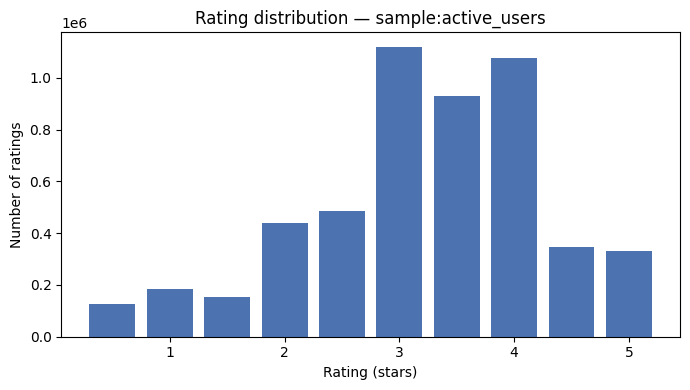

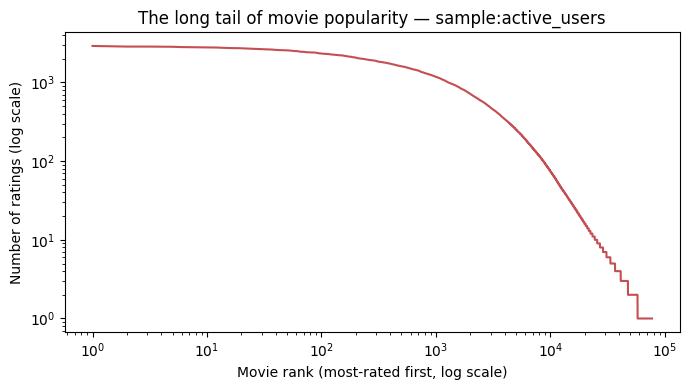

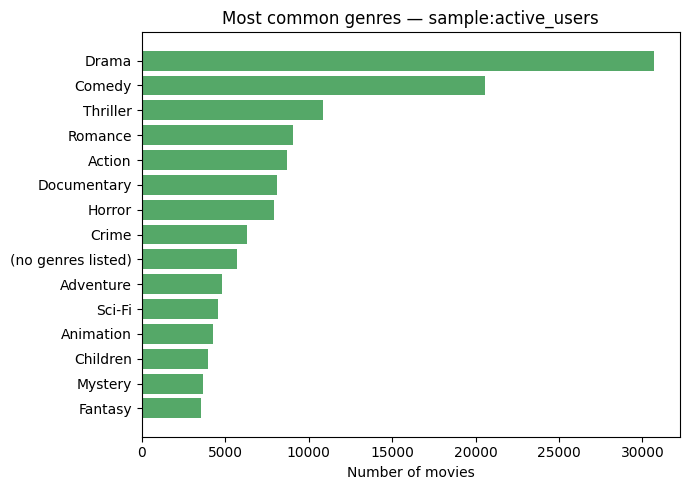

,movieId,title,avg_rating,n_ratings
0,858,"Godfather, The (1972)",4.325,2595
1,318,"Shawshank Redemption, The (1994)",4.304,2812
2,26073,"Human Condition III, The (Ningen no joken III)...",4.288,73
3,159817,Planet Earth (2006),4.284,526
4,170705,Band of Brothers (2001),4.281,631
5,171011,Planet Earth II (2016),4.273,328
6,296,Pulp Fiction (1994),4.244,2862
7,179135,Blue Planet II (2017),4.221,206
8,1203,12 Angry Men (1957),4.206,1863
9,1221,"Godfather: Part II, The (1974)",4.199,2301


In [4]:
ml.eda.plot_rating_distribution(sample); plt.show()
ml.eda.plot_activity_long_tail(sample); plt.show()
ml.eda.plot_genre_counts(sample, top=15); plt.show()
display(ml.eda.top_movies(sample, n=10, min_ratings=50))

## 4. Features

In [5]:
display(ml.features.user_features(sample).head())
display(ml.features.movie_features(sample).head())

,userId,n_ratings,avg_rating,rating_std
0,28,2842,3.422,0.932
1,188,2202,3.453,1.177
2,265,2436,3.484,1.098
3,354,1262,3.677,0.764
4,447,1096,3.276,1.138


,movieId,n_ratings,avg_rating,rating_std,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,1,2698,3.863,0.892,0,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,2208,3.093,0.902,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,3,939,2.764,0.969,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,4,295,2.446,1.004,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,5,984,2.580,0.972,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


## 5. Split (temporal)

In [6]:
split = ml.splitting.split(sample.ratings, strategy="temporal", test_frac=0.2)
print(split)

Split(n_train=4,152,380, n_test=1,038,105)


## 6. Train

In [7]:
to_train = [
    ("global_mean",          ml.models.GlobalMeanModel()),
    ("bias",                 ml.models.BiasModel(reg=10.0)),
    ("matrix_factorization", ml.models.MatrixFactorization(n_factors=20, reg=10.0)),
]
if sample.n_movies <= 5000:
    to_train.append(("item_item_cf", ml.models.ItemItemCF(k_neighbors=30)))

models = {}
for name, model in to_train:
    model.fit(split.train)
    models[name] = model
    print(f"fitted {name}")

fitted global_mean


fitted bias


fitted matrix_factorization


## 7. Evaluate

,model,rmse,mae,precision@10,recall@10,n_ranking_users
0,matrix_factorization,0.800,0.601,0.648,0.099,200
1,bias,0.826,0.623,0.598,0.086,200
2,global_mean,1.018,0.799,0.298,0.031,200


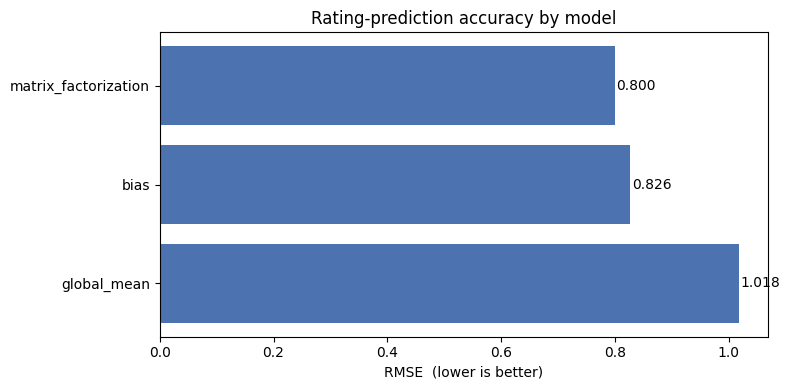

In [8]:
results = [{"model": name, **ml.evaluate.evaluate_model(m, split.test, k=10)}
           for name, m in models.items()]
leaderboard = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
display(leaderboard)

order = leaderboard.sort_values("rmse", ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(order["model"], order["rmse"], color="#4C72B0")
ax.set_xlabel("RMSE  (lower is better)")
ax.set_title("Rating-prediction accuracy by model")
for i, v in enumerate(order["rmse"]):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()

## 8. Recommend

In [9]:
best_name = leaderboard.iloc[0]["model"]
best_model = models[best_name]
example_user = int(sample.ratings["userId"].value_counts().index[0])
print(f"best model: {best_name} | example user: {example_user}")
display(ml.recommend.user_history(sample, example_user, n=8))
display(ml.recommend.recommend_for_user(best_model, sample, example_user, n=10))

best model: matrix_factorization | example user: 175325


,movieId,title,genres,rating
0,64273,"Lovers, The (Les Amants) (1958)",Drama,5.000
1,177005,The Missing Scarf (2013),(no genres listed),5.000
2,71350,Scandal Sheet (1952),Crime|Drama|Film-Noir|Romance|Thriller,5.000
3,180589,Leaning Into the Wind: Andy Goldsworthy (2017),Documentary,5.000
4,26865,Fist of Legend (Jing wu ying xiong) (1994),Action|Drama,5.000
5,670,"World of Apu, The (Apur Sansar) (1959)",Drama,5.000
6,130374,India's Daughter (2015),Documentary,5.000
7,97,"Hate (Haine, La) (1995)",Crime|Drama,5.000


,rank,movieId,title,genres,predicted_rating
0,1,27033,"Kingdom II, The (Riget II) (1997)",Drama|Horror|Mystery,3.973
1,2,179135,Blue Planet II (2017),Documentary,3.949
2,3,720,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy,3.899
3,4,198185,Twin Peaks (1989),Drama|Mystery,3.859
4,5,228099,Firefly (2002),Action|Adventure|Sci-Fi|Western,3.845
5,6,136469,Larry David: Curb Your Enthusiasm (1999),Comedy,3.806
6,7,126106,Beastie Boys: Sabotage (1994),(no genres listed),3.802
7,8,8827,"Bill Cosby, Himself (1983)",Comedy|Documentary,3.800
8,9,171331,The Work of Director Chris Cunningham (2003),(no genres listed),3.768
9,10,171749,Death Note: Desu nôto (2006–2007),(no genres listed),3.764


## 9. Swap samples

In [10]:
for key in ["dense", "random_users"]:
    if key not in ml.sampling.list_saved_samples():
        continue
    ds = ml.sampling.load_sample(key)
    specs = list(ml.pipeline.DEFAULT_MODELS)
    if ds.n_movies > 5000:
        specs = [s for s in specs if s.name != "item_item_cf"]
    print(f"\n===== {key}  ({ds.n_ratings:,} ratings, {ds.n_movies:,} movies) =====")
    res = ml.pipeline.run_pipeline(ds, sample_strategy=None, model_specs=specs, verbose=False)
    display(res.scores[["model", "rmse", "mae", "precision@10", "recall@10"]])


===== dense  (301,416 ratings, 800 movies) =====


,model,rmse,mae,precision@10,recall@10
0,item_item_cf,0.820,0.612,0.684,0.758
1,matrix_factorization,0.837,0.630,0.684,0.757
2,bias,0.860,0.650,0.676,0.749
3,global_mean,0.998,0.780,0.616,0.702



===== random_users  (464,411 ratings, 20,047 movies) =====


,model,rmse,mae,precision@10,recall@10
0,matrix_factorization,0.891,0.680,0.633,0.681
1,bias,0.901,0.689,0.627,0.677
2,global_mean,1.069,0.843,0.555,0.625
